# Notebook 03 (Minimal): LP-IV Short-Run

Goal: estimate short-run LP-IV dynamics of money growth on inflation (h=0..3) and GDP growth (h=0).

In [2]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from linearmodels.iv import IV2SLS
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

BASE = Path('/Users/stevenchung/Desktop/P12B_File/Monetary_Panel')
PANEL_PATH = BASE / '02_data/analysis_ready/macro_growth_merged.csv'
CONTROLS_PATH = BASE / '02_data/supporting/wb_controls_1991_2024.csv'
INSTRUMENTS_PATH = BASE / '02_data/supporting/bartik_instruments_1991_2024.csv'
IT_DATES_PATH = BASE / '02_data/supporting/it_adoption_dates.csv'
OUT_DIR = BASE / '03_analysis_notebooks/exports/03_short_run_lp_iv'
OUT_DIR.mkdir(parents=True, exist_ok=True)

CONTROLS = ['trade_open', 'pop_growth', 'investment_share']
HORIZONS = {'inflation': [0, 1, 2, 3], 'gdp_growth': [0]}
INSTRUMENTS = ['instrument_m2_external_level', 'instrument_m2_l1']
IV_RELEVANCE_CUTOFF, IV_STRONG_CUTOFF = 3.84, 10.0


In [3]:
base = pd.read_csv(PANEL_PATH)
controls = pd.read_csv(CONTROLS_PATH)
instruments = pd.read_csv(INSTRUMENTS_PATH)
it_dates = pd.read_csv(IT_DATES_PATH)

panel = (
    base.merge(controls, on=['Country Name', 'year'], how='left')
        .merge(instruments, on=['Country Name', 'year'], how='left')
        .rename(columns={'Country Name': 'country'})
        .sort_values(['country', 'year'])
        .copy()
)

panel = panel.merge(
    it_dates[['country', 'it_adoption_year_roger2010']],
    on='country',
    how='left',
)
panel['it_group'] = np.where(panel['it_adoption_year_roger2010'].notna(), 'adopter', 'never_adopter')

def exact_horizon(df, var, h):
    col = f'{var}_h{h}'
    if h == 0:
        return df[var].copy()
    lookup = df[['country', 'year', var]].dropna(subset=[var]).rename(columns={var: col}).copy()
    lookup['year'] = lookup['year'] - h
    lookup = lookup.drop_duplicates(['country', 'year'], keep='last')
    return df[['country', 'year']].merge(lookup, on=['country', 'year'], how='left')[col]

lp_panel = panel.copy()
for outcome, hs in HORIZONS.items():
    for h in hs:
        lp_panel[f'{outcome}_h{h}'] = exact_horizon(panel, outcome, h)

fixed_cols = [
    'country', 'year', 'm2_growth', *INSTRUMENTS, *CONTROLS,
    'inflation_h0', 'inflation_h1', 'inflation_h2', 'inflation_h3', 'gdp_growth_h0',
]
fixed_mask = lp_panel[fixed_cols].notna().all(axis=1)

print('fixed sample rows:', int(fixed_mask.sum()))
lp_panel[['country', 'year', 'inflation_h0', 'inflation_h1', 'inflation_h2', 'inflation_h3']].head()


fixed sample rows: 3390


,country,year,inflation_h0,inflation_h1,inflation_h2,inflation_h3
0,Afghanistan,2007,0.083243,0.234429,-0.070542,0.021551
1,Afghanistan,2008,0.234429,-0.070542,0.021551,0.111579
2,Afghanistan,2009,-0.070542,0.021551,0.111579,0.062423
3,Afghanistan,2010,0.021551,0.111579,0.062423,0.071258
4,Afghanistan,2011,0.111579,0.062423,0.071258,0.045681


In [4]:
def run_lp_iv(df, outcome, h, instrument, mask):
    y_col = f'{outcome}_h{h}'
    cols = ['country', 'year', y_col, 'm2_growth', instrument, *CONTROLS]
    fit = df.loc[mask, cols].dropna().copy()
    formula = f"{y_col} ~ 1 + {' + '.join(CONTROLS)} + C(country) + C(year) [m2_growth ~ {instrument}]"
    res = IV2SLS.from_formula(formula, data=fit).fit(cov_type='clustered', clusters=fit['country'])
    fs = res.first_stage.diagnostics.loc['m2_growth']
    b = float(res.params['m2_growth'])
    se = float(res.std_errors['m2_growth'])
    return {
        'outcome': outcome,
        'horizon': h,
        'instrument': instrument,
        'coef_m2_growth': b,
        'std_error': se,
        'p_value': float(res.pvalues['m2_growth']),
        'ci_low_95': b - 1.96 * se,
        'ci_high_95': b + 1.96 * se,
        'nobs': int(res.nobs),
        'first_stage_stat': float(fs['f.stat']),
        'first_stage_p': float(fs['f.pval']),
    }

rows = [
    run_lp_iv(lp_panel, outcome, h, inst, fixed_mask)
    for inst in INSTRUMENTS
    for outcome, hs in HORIZONS.items()
    for h in hs
]
lp_table = pd.DataFrame(rows).sort_values(['instrument', 'outcome', 'horizon']).reset_index(drop=True)

for inst in INSTRUMENTS:
    m = (lp_table['instrument'] == inst) & (lp_table['outcome'] == 'inflation')
    _, p_holm, _, _ = multipletests(lp_table.loc[m, 'p_value'], alpha=0.05, method='holm')
    lp_table.loc[m, 'p_value_holm'] = p_holm
lp_table['p_value_holm'] = lp_table['p_value_holm'].fillna(lp_table['p_value'])

primary = lp_table[lp_table['instrument'] == 'instrument_m2_external_level'].copy()
alt = lp_table[lp_table['instrument'] == 'instrument_m2_l1'].copy()
lp_table


,outcome,horizon,instrument,coef_m2_growth,std_error,p_value,ci_low_95,ci_high_95,nobs,first_stage_stat,first_stage_p,p_value_holm
0,gdp_growth,0,instrument_m2_external_level,-0.171881,0.131011,1.895328e-01,-0.428661,0.084900,3390,6.600583,0.010195,1.895328e-01
1,inflation,0,instrument_m2_external_level,1.223836,0.325442,1.695471e-04,0.585971,1.861702,3390,6.600583,0.010195,6.781883e-04
2,inflation,1,instrument_m2_external_level,0.954454,0.289835,9.909028e-04,0.386378,1.522531,3390,6.600583,0.010195,2.972708e-03
3,inflation,2,instrument_m2_external_level,0.879365,0.308851,4.410401e-03,0.274016,1.484713,3390,6.600583,0.010195,8.820801e-03
4,inflation,3,instrument_m2_external_level,0.696218,0.275597,1.152987e-02,0.156047,1.236388,3390,6.600583,0.010195,1.152987e-02
5,gdp_growth,0,instrument_m2_l1,-0.024225,0.037248,5.154551e-01,-0.097231,0.048781,3390,2.993069,0.083622,5.154551e-01
6,inflation,0,instrument_m2_l1,1.440642,0.280852,2.904516e-07,0.890172,1.991112,3390,2.993069,0.083622,8.713548e-07
7,inflation,1,instrument_m2_l1,0.741992,0.093099,1.554312e-15,0.559518,0.924466,3390,2.993069,0.083622,6.217249e-15
8,inflation,2,instrument_m2_l1,0.332213,0.077087,1.635693e-05,0.181122,0.483303,3390,2.993069,0.083622,3.271387e-05
9,inflation,3,instrument_m2_l1,0.133812,0.080631,9.700274e-02,-0.024225,0.291849,3390,2.993069,0.083622,9.700274e-02


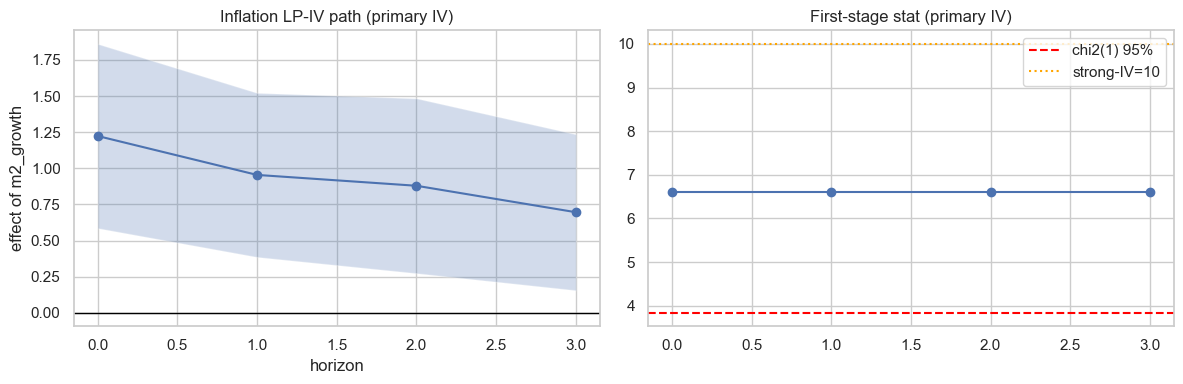

,metric,value
0,inflation_sig_horizons_5pct_unadjusted,4
1,inflation_sig_horizons_5pct_holm,4
2,gdp_sig_horizons_5pct,0
3,inflation_min_first_stage_stat_primary,6.600583
4,inflation_relevance_gate_all_horizons,True
5,inflation_strong_iv_all_horizons,False
6,fixed_sample_rows,3390


In [5]:
infl = primary[primary['outcome'] == 'inflation'].sort_values('horizon')
gdp = primary[primary['outcome'] == 'gdp_growth'].sort_values('horizon')

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(infl['horizon'], infl['coef_m2_growth'], marker='o')
ax[0].fill_between(infl['horizon'], infl['ci_low_95'], infl['ci_high_95'], alpha=0.25)
ax[0].axhline(0, color='black', linewidth=1)
ax[0].set_title('Inflation LP-IV path (primary IV)')
ax[0].set_xlabel('horizon')
ax[0].set_ylabel('effect of m2_growth')

ax[1].plot(infl['horizon'], infl['first_stage_stat'], marker='o')
ax[1].axhline(IV_RELEVANCE_CUTOFF, color='red', linestyle='--', label='chi2(1) 95%')
ax[1].axhline(IV_STRONG_CUTOFF, color='orange', linestyle=':', label='strong-IV=10')
ax[1].set_title('First-stage stat (primary IV)')
ax[1].legend()
fig.tight_layout()
fig.savefig(OUT_DIR / '03_inflation_lp_and_first_stage.png', dpi=170)
plt.show()

summary = pd.DataFrame([
    {'metric': 'inflation_sig_horizons_5pct_unadjusted', 'value': int((infl['p_value'] < 0.05).sum())},
    {'metric': 'inflation_sig_horizons_5pct_holm', 'value': int((infl['p_value_holm'] < 0.05).sum())},
    {'metric': 'gdp_sig_horizons_5pct', 'value': int((gdp['p_value'] < 0.05).sum())},
    {'metric': 'inflation_min_first_stage_stat_primary', 'value': float(infl['first_stage_stat'].min())},
    {'metric': 'inflation_relevance_gate_all_horizons', 'value': bool((infl['first_stage_stat'] > IV_RELEVANCE_CUTOFF).all())},
    {'metric': 'inflation_strong_iv_all_horizons', 'value': bool((infl['first_stage_stat'] >= IV_STRONG_CUTOFF).all())},
    {'metric': 'fixed_sample_rows', 'value': int(fixed_mask.sum())},
])
summary


In [6]:
strat_rows = []
for group in ['adopter', 'never_adopter']:
    m = fixed_mask & (lp_panel['it_group'] == group)
    for h in HORIZONS['inflation']:
        row = run_lp_iv(lp_panel, 'inflation', h, 'instrument_m2_external_level', m)
        row['it_group'] = group
        strat_rows.append(row)
strat_table = pd.DataFrame(strat_rows).sort_values(['it_group', 'horizon']).reset_index(drop=True)

lp_table.to_csv(OUT_DIR / '03_lp_iv_all_results.csv', index=False)
primary.to_csv(OUT_DIR / '03_lp_iv_primary_results.csv', index=False)
alt.to_csv(OUT_DIR / '03_lp_iv_alt_results.csv', index=False)
strat_table.to_csv(OUT_DIR / '03_lp_iv_it_stratified.csv', index=False)
summary.to_csv(OUT_DIR / '03_interpretation_metrics.csv', index=False)

print('Saved outputs to:', OUT_DIR)
strat_table


Saved outputs to: /Users/stevenchung/Desktop/P12B_File/Monetary_Panel/03_analysis_notebooks/exports/03_short_run_lp_iv


,outcome,horizon,instrument,coef_m2_growth,std_error,p_value,ci_low_95,ci_high_95,nobs,first_stage_stat,first_stage_p,it_group
0,inflation,0,instrument_m2_external_level,0.782942,0.414457,0.058881,-0.029394,1.595278,676,1.431106,0.231584,adopter
1,inflation,1,instrument_m2_external_level,0.845857,0.451569,0.061048,-0.039219,1.730934,676,1.431106,0.231584,adopter
2,inflation,2,instrument_m2_external_level,0.680694,0.386349,0.078092,-0.076550,1.437937,676,1.431106,0.231584,adopter
3,inflation,3,instrument_m2_external_level,0.588237,0.456481,0.197526,-0.306466,1.482940,676,1.431106,0.231584,adopter
4,inflation,0,instrument_m2_external_level,1.453608,0.557262,0.009094,0.361375,2.545842,2714,3.207415,0.073305,never_adopter
5,inflation,1,instrument_m2_external_level,1.089862,0.468074,0.019891,0.172437,2.007287,2714,3.207415,0.073305,never_adopter
6,inflation,2,instrument_m2_external_level,1.053500,0.527480,0.045800,0.019639,2.087362,2714,3.207415,0.073305,never_adopter
7,inflation,3,instrument_m2_external_level,0.824133,0.446737,0.065069,-0.051472,1.699738,2714,3.207415,0.073305,never_adopter


## Plain-English takeaway

- Primary IV LP coefficients for inflation are positive from h=0 to h=3.
- GDP short-run response (h=0) is not significant.
- First stage is relevant but not strong (below 10), so treat as directional evidence.